In [1]:
#SJL 6/2020
#Script to plot the change in surface length for planets in the canonical model


###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

import scipy.integrate as integrate
from scipy.optimize import curve_fit

#package to use wildcards 
import fnmatch

from scipy.interpolate import LinearNDInterpolator
#from matplotlib.mlab import griddata
from scipy.interpolate import griddata

#plotting packages
import matplotlib as mpl
#mpl.use('PDF')
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec

cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")


#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')


/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

In [2]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

In [3]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#reference flaf (0: to a set planet, 1: to an interpolated AM value)
flag_ref=1

L_present=(LEM)-(MMoon)*np.sqrt(const.G*aMoon*MEarth)
L_compare=L_present
print(L_present/LEM)
print(((LEM)-(MMoon)*np.sqrt(const.G*aRoche*MEarth))/LEM)
AMref=str(L_compare/LEM)


#number of contor lines
Ncont=20

#flags for which plot to use
flag_single_column=1
flag_two_column=1

#select crust amounts to plot
Ncrust=[1.,3.0,10]
Mfpoints=np.asarray(Ncrust)*2.77E22/MEarth
print(Mfpoints)


#directory to put plots
plot_dir='Movie_slides'
if os.path.isdir(plot_dir)==False:
    os.mkdir(plot_dir)

0.17825658589994117
0.8198445751780722
[0.00463831 0.01391494 0.04638312]


In [4]:
########################################################################################
########################################################################################
########################################################################################
#MAIN

########################################################################################
#read in the database

Hdatabase=HERCULES_random_planet_database_1D()
Hdatabase.make_array(Hdir,Hname)
Hdatabase.initialize_interpolation([0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1],\
                                   [0,0,Mfpoints.tolist(),0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]], flag_extrap=1)

#extract the latitudes for each Mu point
Nmu=Hdatabase.parr[0].Nmu
lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi

#     temp_data=Hdatabase.interp_database(L_compare,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
#                                        [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)
    
#     temp=np.asarray(temp_data[16])
    
#     dl_lat_comp=temp[:,0]
#     dl_lon_comp=temp[:,1]
#     dA_comp=temp[:,2]

Earth_correct_params_S3.20c
	 Earth_correct_params_S3.20c_AM3.3125
	 Earth_correct_params_S3.20c_AM3.30625
	 Earth_correct_params_S3.20c_AM3.325


In [5]:
########################################################
########################################################
#calculate the pattern and rate of deformation for an example tidal evolution for contout plot
print('begin')

#constants
k2Q=0.3/100.0
a0=2.9*REarth
Ltot=LEM

Nt=100

t=np.linspace(0.1,20,Nt)*1E6*const.year

#calculate the orbit
kappa=3.0*k2Q*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))
a=((13.0/2.0)*(kappa*t+(2.0/13.0)*(a0**(13.0/2.0))))**(2.0/13.0)
L=Ltot-(MMoon)*np.sqrt(const.G*a*(MEarth+MMoon))
dLdt=-0.5*MMoon/np.sqrt(const.G*a*(MEarth+MMoon))*const.G*(MEarth+MMoon)*kappa*(a**(-11.0/2.0))

#run through and extract lengths and areas at each time point
dl_lat=np.zeros((Nt,Nmu))
dl_lon=np.zeros((Nt,Nmu))
dA=np.zeros((Nt,Nmu))

ddl_lat_dL=np.zeros((Nt,Nmu))
ddl_lon_dL=np.zeros((Nt,Nmu))
ddA_dL=np.zeros((Nt,Nmu))

ddl_lat_dt=np.zeros((Nt,Nmu))
ddl_lon_dt=np.zeros((Nt,Nmu))
ddA_dt=np.zeros((Nt,Nmu))

rsurf=np.zeros((Nt,Nmu))


#now loop through and find the deformation rates
for i in np.arange(Nt):
    print(i,'/',Nt)
     
    temp_data=Hdatabase.interp_database(L[i],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1],\
                                       [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)

    temp=np.asarray(temp_data[16])

    dl_lat[i,:]=temp[:,0]
    dl_lon[i,:]=temp[:,1]
    dA[i,:]=temp[:,2]

    ddl_lat_dL[i,:]=temp[:,3]
    ddl_lon_dL[i,:]=temp[:,4]
    ddA_dL[i,:]=temp[:,5]

    ddl_lat_dt[i,:]=temp[:,3]*dLdt[i]
    ddl_lon_dt[i,:]=temp[:,4]*dLdt[i]
    ddA_dt[i,:]=temp[:,5]*dLdt[i]
    
    rsurf[i,:]=np.asarray(temp_data[17])
    
    
print('end')


begin
0 / 100
1 / 100
2 / 100
3 / 100
4 / 100
5 / 100
6 / 100
7 / 100
8 / 100
9 / 100
10 / 100
11 / 100
12 / 100
13 / 100
14 / 100
15 / 100
16 / 100
17 / 100
18 / 100
19 / 100
20 / 100
21 / 100
22 / 100
23 / 100
24 / 100
25 / 100
26 / 100
27 / 100
28 / 100
29 / 100
30 / 100
31 / 100
32 / 100
33 / 100
34 / 100
35 / 100
36 / 100
37 / 100
38 / 100
39 / 100
40 / 100
41 / 100
42 / 100
43 / 100
44 / 100
45 / 100
46 / 100
47 / 100
48 / 100
49 / 100
50 / 100
51 / 100
52 / 100
53 / 100
54 / 100
55 / 100
56 / 100
57 / 100
58 / 100
59 / 100
60 / 100
61 / 100
62 / 100
63 / 100
64 / 100
65 / 100
66 / 100
67 / 100
68 / 100
69 / 100
70 / 100
71 / 100
72 / 100
73 / 100
74 / 100
75 / 100
76 / 100
77 / 100
78 / 100
79 / 100
80 / 100
81 / 100
82 / 100
83 / 100
84 / 100
85 / 100
86 / 100
87 / 100
88 / 100
89 / 100
90 / 100
91 / 100
92 / 100
93 / 100
94 / 100
95 / 100
96 / 100
97 / 100
98 / 100
99 / 100
end


In [6]:
print('begin cat')

#calculate the interpolation hulls
lat_grid=np.linspace(0, 90, Ncont*(Ncont+1))
t_grid=np.linspace(np.amin(t), np.amax(t),Ncont*(Ncont+1))/const.year/1E6

#make the controur grids
LLL, TTT = np.meshgrid(t_grid, lat_grid)

temp=np.ones(np.shape(ddl_lat_dt))
time_arr=temp*t[:, None]
lat_arr=temp*lat[None,:]

#interpolate onto grid
DLON=griddata(((time_arr.flatten()/const.year/1E6,90.0-lat_arr.flatten())),ddl_lon_dt.flatten()*const.year*np.pi/180.0,(LLL,TTT))#, method='linear')
DLAT=griddata(((time_arr.flatten()/const.year/1E6,90.0-lat_arr.flatten())),ddl_lat_dt.flatten()*const.year*np.pi/180.0,(LLL,TTT))#, method='linear')
AAA=griddata(((time_arr.flatten()/const.year/1E6,90.0-lat_arr.flatten())),ddA_dt.flatten()*const.year*(np.pi/180.0)**2,(LLL,TTT))#, method='linear')

print('end cat')


begin cat
end cat


In [7]:
#Also run a set of calculations that go earlier in time for a and L

t_plot=np.logspace(-10,np.log10(20),100*Nt)*1E6*const.year

#run through and extract lengths and areas at each time point
kappa=3.0*k2Q*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))
a_plot=((13.0/2.0)*(kappa*t_plot+(2.0/13.0)*(a0**(13.0/2.0))))**(2.0/13.0)
L_plot=Ltot-(MMoon)*np.sqrt(const.G*a_plot*(MEarth+MMoon))

begin lobster


/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_8288/649904916.py:62: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour10 = ax[0][2].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[0.0], colors=['k'], linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_8288/649904916.py:65: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour20 = ax[0][3].contour(LLL, TTT, DLON, linewidth=1.5, levels=[0.0], colors=['k'],linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_8288/649904916.py:68: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour30 = ax[0][4].contour(LLL, TTT, AAA, linewidth=1.5, levels=[0], colors=['k'], linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_8288/649904916.py:96: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.

38.755319018062806
end lobster


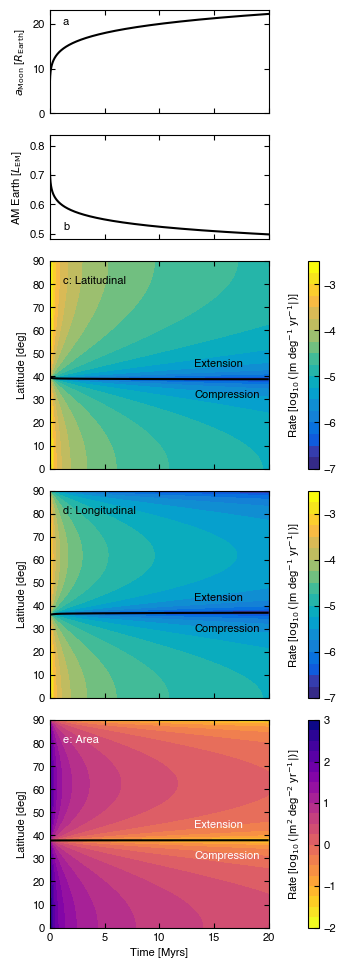

In [8]:
print('begin lobster')
#plot the contour plot for deformation as a function of latitude


#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure6.pdf')
mpl.pyplot.close(fig)


#initialise the real figure
fig = plt.figure(figsize=(3.5,9.724))
gs = gridspec.GridSpec(5, 2,
                      width_ratios=[1,0.05],
                      height_ratios=[0.5,0.5,1,1,1])
ax=[[]]
ax[0].append(plt.subplot(gs[0]))
ax[0].append(plt.subplot(gs[2], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[4], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[6], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[8], sharex=ax[0][0]))

ax_col=[[]]
ax_col[0].append(plt.subplot(gs[5]))
ax_col[0].append(plt.subplot(gs[7]))
ax_col[0].append(plt.subplot(gs[9]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)


ax[0][0].plot(t_plot/const.year/1E6, a_plot/REarth, 'k-', linewidth=1.5)

ax[0][1].plot(t_plot/const.year/1E6, L_plot/LEM, 'k-', linewidth=1.5)a

lat_contours=np.linspace(-7,-2.5,18+1)
lon_contours=np.linspace(-7,-2.5,18+1)
Acontours=np.linspace(-2,3,20+1)

lat_labels=np.asarray([-7,-6,-5,-4,-3])
lon_labels=np.asarray([-7,-6,-5,-4,-3])
Alabels=np.asarray([-2,-1,0,1,2,3])

contour1 = ax[0][2].contourf(LLL, TTT, np.log10(np.absolute(DLAT)), levels=lat_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lat_contours)-1)))
contour10 = ax[0][2].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[0.0], colors=['k'], linestyles='solid')
#temp = ax[0][0].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[-4,4], colors=['k'], linestyles='dashed')
contour2 = ax[0][3].contourf(LLL, TTT, np.log10(np.absolute(DLON)), levels=lon_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lon_contours)-1)))
contour20 = ax[0][3].contour(LLL, TTT, DLON, linewidth=1.5, levels=[0.0], colors=['k'],linestyles='solid')
#temp = ax[0][1].contour(LLL, TTT, DLON, linewidth=1.5, levels=[-4,4], colors=['k'], linestyles='dashed')
contour3 = ax[0][4].contourf(LLL, TTT, np.log10(np.absolute(AAA)), levels=Acontours, colors=cm.plasma(np.linspace(1, 0, np.size(Acontours)-1)))
contour30 = ax[0][4].contour(LLL, TTT, AAA, linewidth=1.5, levels=[0], colors=['k'], linestyles='solid')
#temp = ax[0][2].contour(LLL, TTT, AAA/1E6, linewidth=1.5, levels=[-10,10], colors=['k'], linestyles='dashed')

ax[0][0].set_ylabel(r"$a_\mathrm{Moon}$ [$R_\mathrm{Earth}$]")
ax[0][1].set_ylabel(r"AM Earth [$L_\mathrm{EM}$]")
ax[0][2].set_ylabel("Latitude [deg]")
ax[0][3].set_ylabel("Latitude [deg]")
ax[0][4].set_ylabel("Latitude [deg]")
ax[0][4].set_xlabel(r"Time [Myrs]")

for i in np.arange(5):
    if i!=4: plt.setp( ax[0][i].get_xticklabels(), visible=False)
    ax[0][i].tick_params(direction="in", top=True, right=True)

ax[0][0].set_xlim([0, np.amax(t)/const.year/1E6])
ax[0][1].set_xlim([0, np.amax(t)/const.year/1E6])
ax[0][2].set_xlim([0, np.amax(t)/const.year/1E6])
ax[0][3].set_xlim([0, np.amax(t)/const.year/1E6])
ax[0][4].set_xlim([0, np.amax(t)/const.year/1E6])


#label axis
ax[0][0].text(0.06, 0.93, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.06, 0.07, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[0][2].text(0.06, 0.93, 'c: Latitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.06, 0.93, 'd: Longitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][4].text(0.06, 0.93, 'e: Area', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][4].transAxes, color='w')

print(contour10.allsegs[-1][-1][-1])
ax[0][2].text(0.66, contour10.allsegs[-1][-1][-1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][2].text(0.66, contour10.allsegs[-1][-1][-1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.66, contour20.allsegs[-1][-1][-1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][3].text(0.66, contour20.allsegs[-1][-1][-1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][4].text(0.66, contour30.allsegs[-1][-1][-1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][4].transAxes, color='w')
ax[0][4].text(0.66, contour30.allsegs[-1][-1][-1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][4].transAxes, color='w')


cbar1=plt.colorbar(contour1, cax=ax_col[0][0], orientation='vertical',ticks=lat_labels)
cbar2=plt.colorbar(contour2, cax=ax_col[0][1], orientation='vertical',ticks=lon_labels)
cbar3=plt.colorbar(contour3, cax=ax_col[0][2], orientation='vertical',ticks=Alabels)


cbar1.set_label('Rate [$\log_{10} (|$m deg$^{-1}$ yr$^{-1}$$|)$]', labelpad=-36)
cbar2.set_label(r'Rate [$\log_{10} (|$m deg$^{-1}$ yr$^{-1}$$|)$]', labelpad=-36)
cbar3.set_label(r'Rate [$\log_{10} (|$m$^2$ deg$^{-2}$ yr$^{-1}$$|)$]', labelpad=-36)

for i in np.arange(3):
    ax_col[0][i].tick_params(direction="in")
    
ax[0][0].set_yticks([0,10,20])

fig.tight_layout()

plt.savefig('Figure6.pdf')

print('end lobster')

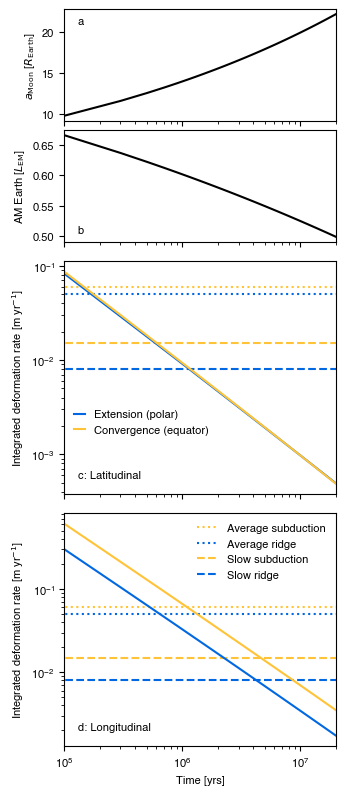

In [9]:
#plot the maximum and minimum deformation rates as a function of time
#This one I plot the integrated deformation rate in latitude/longitude
#the pretty version
#Now with orbital evolution


#initialise the figure
fig = plt.figure(figsize=(3.5,8.0))
gs = gridspec.GridSpec(3, 1,
                      width_ratios=[1],
                      height_ratios=[1,1,1])


gs000 = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=gs[0],
                                        height_ratios=[1,1],
                                        )

ax=[[]]
ax[0].append(plt.subplot(gs[1]))
ax[0].append(plt.subplot(gs[2], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs000[0], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs000[1], sharex=ax[0][0]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)

col=cmaps.parula([0.15,0.85])



ddl_lat_dt_max=np.zeros(Nt)*np.nan
ddl_lat_dt_min=np.zeros(Nt)*np.nan

ddl_lon_dt_max=np.zeros(Nt)*np.nan
ddl_lon_dt_min=np.zeros(Nt)*np.nan


ind_max=Nt-1
for i in np.arange(ind_max):
    #longitudinal is easy. Accomodated around minor circle
    ddl_lon_dt_max[i]=np.amax(ddl_lon_dt[i,:])*const.year*2*np.pi
    ddl_lon_dt_min[i]=np.amin(ddl_lon_dt[i,:])*const.year*2*np.pi
    
    
    #latitudinal is harder. Need to integrate over surface
    temp=np.where(ddl_lat_dt[i,:]<0)[0][-1]
    
    #print(lat[0:temp])
    ddl_lat_dt_min[i]=2*integrate.trapz(ddl_lat_dt[i,0:temp]*const.year*np.pi/180.0,90.0-lat[0:temp])
    ddl_lat_dt_max[i]=integrate.trapz(ddl_lat_dt[i,(temp+1):]*const.year*np.pi/180.0,90.0-lat[(temp+1):])


ax[0][0].plot([0,t[ind_max]/const.year],[8E-3,8E-3],'--', color=col[0],linewidth=1.5) #slow mid ocean ridge
ax[0][0].plot([0,t[ind_max]/const.year],[15E-3,15E-3],'--', color=col[1],linewidth=1.5) #slow subduction
ax[0][0].plot([0,t[ind_max]/const.year],[50E-3,50E-3],':', color=col[0],linewidth=1.5) #average mid-ocean ridge
ax[0][0].plot([0,t[ind_max]/const.year],[60E-3,60E-3],':', color=col[1],linewidth=1.5) #avererage subduction

ax[0][1].plot([0,t[ind_max]/const.year],[60E-3,60E-3],':', color=col[1],linewidth=1.5, label='Average subduction') #avererage subduction
ax[0][1].plot([0,t[ind_max]/const.year],[50E-3,50E-3],':', color=col[0],linewidth=1.5, label='Average ridge') #average mid-ocean ridge
ax[0][1].plot([0,t[ind_max]/const.year],[15E-3,15E-3],'--', color=col[1],linewidth=1.5, label='Slow subduction') #slow subduction
ax[0][1].plot([0,t[ind_max]/const.year],[8E-3,8E-3],'--', color=col[0],linewidth=1.5, label='Slow ridge') #slow mid ocean ridge
    
ax[0][0].plot(t/const.year, np.absolute(ddl_lat_dt_max),'-', color=col[0],linewidth=1.5,label='Extension (polar)')
ax[0][0].plot(t/const.year, np.absolute(ddl_lat_dt_min),'-', color=col[1],linewidth=1.5,label='Convergence (equator)')

ax[0][1].plot(t/const.year, np.absolute(ddl_lon_dt_max),'-', color=col[0],linewidth=1.5)
ax[0][1].plot(t/const.year, np.absolute(ddl_lon_dt_min),'-', color=col[1],linewidth=1.5)

#plot orbital evolution
ax[0][2].plot(t/const.year, a/REarth, 'k-', linewidth=1.5)

ax[0][3].plot(t/const.year, L/LEM, 'k-', linewidth=1.5)

ax[0][0].set_xlim([1E5,2E7])


ax[0][0].set_yscale('log')
ax[0][1].set_yscale('log')


ax[0][0].set_xscale('log')
ax[0][1].set_xscale('log')
ax[0][2].set_xscale('log')
ax[0][3].set_xscale('log')

ax[0][0].set_ylabel('Integrated deformation rate [m yr$^{-1}$]')
ax[0][1].set_ylabel('Integrated deformation rate [m yr$^{-1}$]')

ax[0][2].set_ylabel(r"$a_{\rm Moon}$ [$R_{\rm Earth}$]")
ax[0][3].set_ylabel(r"AM Earth [$L_{\rm EM}$]")

ax[0][1].set_xlabel('Time [yrs]')

plt.setp( ax[0][0].get_xticklabels(), visible=False)
plt.setp( ax[0][2].get_xticklabels(), visible=False)
plt.setp( ax[0][3].get_xticklabels(), visible=False)


ax[0][0].legend(frameon=False, handlelength=1.0, loc='lower left',bbox_to_anchor=(0.0, 0.21))
ax[0][1].legend(frameon=False, handlelength=1.9, loc='upper right')#,bbox_to_anchor=(0.98, 1.36))

ax[0][2].text(0.05, 0.94, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.05, 0.06, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][3].transAxes, color='k')
  
ax[0][0].text(0.05, 0.06, 'c: Latitudinal', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.05, 0.06, 'd: Longitudinal', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
               

fig.tight_layout()
plt.savefig('Figure5.pdf')



In [10]:
########################################################
########################################################
#Now look at how the rate of change of surface shape with AM
#also compares calculating the rate of change in interp_database vs taking the derivative of the lenghts
#tldr: Better to find rates before interp

Nplot=50
L=np.linspace(0.18,0.82,Nplot)*LEM
#L=np.linspace(0.18,2,Nplot)*LEM
deltaL=1E-5*LEM

#calculate legnths then take gradient
ddl_lat_dL=np.zeros((Nplot,Nmu))
ddl_lon_dL=np.zeros((Nplot,Nmu))
ddA_dL=np.zeros((Nplot,Nmu))

#calculating gradient before interpolation
ddl_lat_dL_native=np.zeros((Nplot,Nmu))
ddl_lon_dL_native=np.zeros((Nplot,Nmu))
ddA_dL_native=np.zeros((Nplot,Nmu))

#temporary arrays
dl_lat=np.empty((3,Nmu))
dl_lon=np.empty((3,Nmu))
dA=np.empty((3,Nmu))

for i in np.arange(Nplot):
    print(i)
    Lcalc=np.asarray([L[i]-deltaL,L[i],L[i]+deltaL])
    
    for k in np.arange(3):
        temp_data=Hdatabase.interp_database(Lcalc[k],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                               [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)

        temp=np.asarray(temp_data[16])

        dl_lat[k,:]=temp[:,0]
        dl_lon[k,:]=temp[:,1]
        dA[k,:]=temp[:,2]
        
        if k==1:
            ddl_lat_dL_native[i,:]=temp[:,3]*np.pi/180.0
            ddl_lon_dL_native[i,:]=temp[:,4]*np.pi/180.0
            ddA_dL_native[i,:]=temp[:,5]*(np.pi/180.0)**2
        
    
    for k in np.arange(Nmu):
        ddl_lat_dL[i,k]=gradient2(Lcalc/LEM,dl_lat[:,k])[1]*np.pi/180.0
        ddl_lon_dL[i,k]=gradient2(Lcalc/LEM,dl_lon[:,k])[1]*np.pi/180.0
        ddA_dL[i,k]=gradient2(Lcalc/LEM,dA[:,k])[1]*(np.pi/180.0)**2
            
print('done')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
done


In [11]:
#############################################################
#now look at how well ddl/dL follow a power law and what is the exponent
#first calculate the fits
def power_law(x,b,c):
    return b*(x**c)

#Take an array of mu points
indmu=np.arange(Hdatabase.parr[0].Nmu)

#initialize fit and variance arrays
lat_fit_mu=np.empty([2,Hdatabase.parr[0].Nmu])
lon_fit_mu=np.empty([2,Hdatabase.parr[0].Nmu])
A_fit_mu=np.empty([2,Hdatabase.parr[0].Nmu])

lat_pcov_mu=np.empty([2,Hdatabase.parr[0].Nmu])
lon_pcov_mu=np.empty([2,Hdatabase.parr[0].Nmu])
A_pcov_mu=np.empty([2,Hdatabase.parr[0].Nmu])

#loop through and fit the power law
for i in indmu:
    
    lat_fit_mu[:,i], pcov = curve_fit(power_law, L/LEM, ddl_lat_dL_native[:,i]*LEM,p0=[1E3,0.9],maxfev = 8000)
    lat_pcov_mu[:,i]=np.diagonal(pcov)
    lon_fit_mu[:,i], pcov = curve_fit(power_law, L/LEM, ddl_lon_dL_native[:,i]*LEM,p0=[1E4,0.9],maxfev = 8000)
    lon_pcov_mu[:,i]=np.diagonal(pcov)
    A_fit_mu[:,i], pcov = curve_fit(power_law, L/LEM, ddA_dL_native[:,i]*LEM,p0=[1E8,0.9],maxfev = 8000)
    A_pcov_mu[:,i]=np.diagonal(pcov)

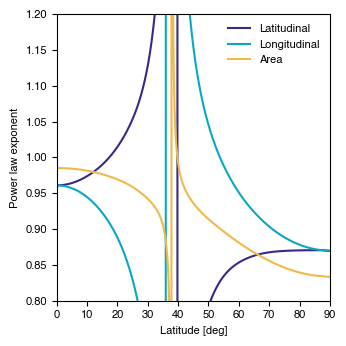

In [13]:
#plot for paper just looking at the power

#initialise the figure
fig = plt.figure(figsize=(3.5,3.5))
gs = gridspec.GridSpec(1, 1)
ax=[[]]
ax[0].append(plt.subplot(gs[0]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)

col=cmaps.parula(np.linspace(0,0.8,3))

#plot the fits and covariances
ax[0][0].plot(90.0-lat,lat_fit_mu[1,:],'-',color=col[0],label='Latitudinal')
ax[0][0].plot(90.0-lat,lon_fit_mu[1,:],'-',color=col[1],label='Longitudinal')
ax[0][0].plot(90.0-lat,A_fit_mu[1,:],'-',color=col[2],label='Area')

ax[0][0].set_ylim([0.8,1.2])
ax[0][0].set_xlim([0,90])
ax[0][0].set_xticks(np.arange(0,10)*10)


ax[0][0].set_xlabel('Latitude [deg]')
ax[0][0].set_ylabel('Power law exponent')

ax[0][0].legend(frameon=False)

fig.tight_layout()

plt.savefig('FigureA2.pdf')



In [17]:
########################################################
########################################################
#plot deformation rates as lines of constant time as a function of k2Q
#this is to examine the dependence on k2Q

#only Ltot is held constant
Ltot=LEM

#k2Q array
Nk2Q=100
k2Q=np.logspace(-5,0,Nk2Q)

#time array
t=np.asarray([0.0,0.1,1,10,100])*const.year*1E6
Nt=np.size(t)

#a0 array
a0=np.asarray([2.9,5,10])*REarth
Na0=np.size(a0)

            
#run through and extract orbital elements, lengths and areas at each time point
a=np.zeros((Nt,Na0,Nk2Q))
L=np.zeros((Nt,Na0,Nk2Q))

dLdt=np.zeros((Nt,Na0,Nk2Q))

dl_lat=np.empty((Nt,Na0,Nk2Q,Nmu))
dl_lon=np.empty((Nt,Na0,Nk2Q,Nmu))
dA=np.empty((Nt,Na0,Nk2Q,Nmu))

ddl_lat_dL=np.zeros((Nt,Na0,Nk2Q,Nmu))
ddl_lon_dL=np.zeros((Nt,Na0,Nk2Q,Nmu))
ddA_dL=np.zeros((Nt,Na0,Nk2Q,Nmu))

ddl_lat_dt=np.zeros((Nt,Na0,Nk2Q,Nmu))
ddl_lon_dt=np.zeros((Nt,Na0,Nk2Q,Nmu))
ddA_dt=np.zeros((Nt,Na0,Nk2Q,Nmu))


for kk in np.arange(Na0): 
    print(kk+1,'/',Na0)
    for i in np.arange(Nk2Q):
        print('\t',i,'/',Nk2Q)

        #calculate the orbit
        kappa=3.0*k2Q[i]*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))
        a[:,kk,i]=((13.0/2.0)*(kappa*t+(2.0/13.0)*(a0[kk]**(13.0/2.0))))**(2.0/13.0)
        L[:,kk,i]=Ltot-(MMoon)*np.sqrt(const.G*a[:,kk,i]*(MEarth+MMoon))
        dLdt[:,kk,i]=-0.5*MMoon/np.sqrt(const.G*a[:,kk,i]*(MEarth+MMoon))*const.G*(MEarth+MMoon)*kappa*(a[:,kk,i]**(-11.0/2.0))

        
        for j in np.arange(Nt):

            # print('\t\t',j,'/',Nt)

            temp_data=Hdatabase.interp_database(L[j,kk,i],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                               [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)

            temp=np.asarray(temp_data[16])

            dl_lat[j,kk,i,:]=temp[:,0]
            dl_lon[j,kk,i,:]=temp[:,1]
            dA[j,kk,i,:]=temp[:,2]

            ddl_lat_dL[j,kk,i,:]=temp[:,3]*np.pi/180.0
            ddl_lon_dL[j,kk,i,:]=temp[:,4]*np.pi/180.0
            ddA_dL[j,kk,i,:]=temp[:,5]*(np.pi/180.0)**2

            ddl_lat_dt[j,kk,i,:]=temp[:,3]*dLdt[j,kk,i]*np.pi/180.0
            ddl_lon_dt[j,kk,i,:]=temp[:,4]*dLdt[j,kk,i]*np.pi/180.0
            ddA_dt[j,kk,i,:]=temp[:,5]*dLdt[j,kk,i]*(np.pi/180.0)**2
            
            
print('done')

1 / 3
	 0 / 100
	 1 / 100
	 2 / 100
	 3 / 100
	 4 / 100
	 5 / 100
	 6 / 100
	 7 / 100
	 8 / 100
	 9 / 100
	 10 / 100
	 11 / 100
	 12 / 100
	 13 / 100
	 14 / 100
	 15 / 100
	 16 / 100
	 17 / 100
	 18 / 100
	 19 / 100
	 20 / 100
	 21 / 100
	 22 / 100
	 23 / 100
	 24 / 100
	 25 / 100
	 26 / 100
	 27 / 100
	 28 / 100
	 29 / 100
	 30 / 100
	 31 / 100
	 32 / 100
	 33 / 100
	 34 / 100
	 35 / 100
	 36 / 100
	 37 / 100
	 38 / 100
	 39 / 100
	 40 / 100
	 41 / 100
	 42 / 100
	 43 / 100
	 44 / 100
	 45 / 100
	 46 / 100
	 47 / 100
	 48 / 100
	 49 / 100
	 50 / 100
	 51 / 100
	 52 / 100
	 53 / 100
	 54 / 100
	 55 / 100
	 56 / 100
	 57 / 100
	 58 / 100
	 59 / 100
	 60 / 100
	 61 / 100
	 62 / 100
	 63 / 100
	 64 / 100
	 65 / 100
	 66 / 100
	 67 / 100
	 68 / 100
	 69 / 100
	 70 / 100
	 71 / 100
	 72 / 100
	 73 / 100
	 74 / 100
	 75 / 100
	 76 / 100
	 77 / 100
	 78 / 100
	 79 / 100
	 80 / 100
	 81 / 100
	 82 / 100
	 83 / 100
	 84 / 100
	 85 / 100
	 86 / 100
	 87 / 100
	 88 / 100
	 89 / 100
	 90 / 100
	 9

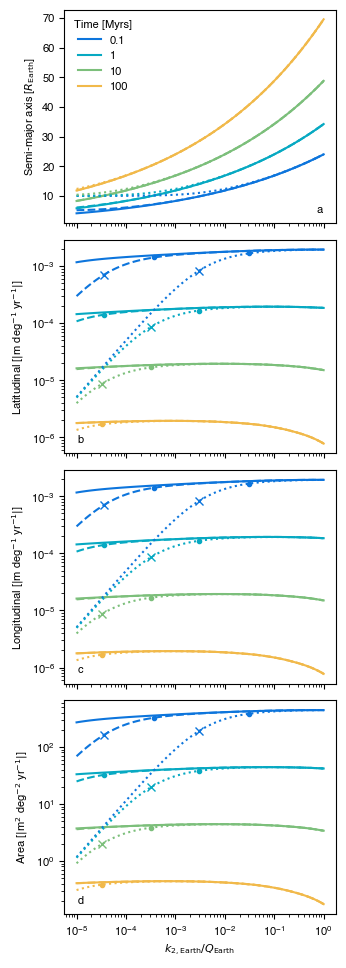

In [19]:
#plot the publication quality figure
#initialise the figure
fig = plt.figure(figsize=(3.5,9.724))
#fig = plt.figure(figsize=(3.5,25))
gs = gridspec.GridSpec(4, 1)

ax=[[]]
ax[0].append(plt.subplot(gs[0]))
ax[0].append(plt.subplot(gs[1]))
ax[0].append(plt.subplot(gs[2]))
ax[0].append(plt.subplot(gs[3]))

indmu=0

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)

labels=['0.0','0.1','1','10','100']

lines=['-','--',':']
col=cmaps.parula(np.linspace(0,0.8,Nt))

for kk in np.arange(Na0):
    for i in np.arange(Nt)[1:]:
        if kk==0:
            ax[0][0].plot(k2Q,a[i,kk,:]/REarth,lines[kk],color=col[i],label=labels[i])
        else:
            ax[0][0].plot(k2Q,a[i,kk,:]/REarth,lines[kk],color=col[i])
        
        ax[0][1].plot(k2Q,np.absolute(ddl_lat_dt[i,kk,:,indmu])*const.year,lines[kk],color=col[i])
        ax[0][2].plot(k2Q,np.absolute(ddl_lon_dt[i,kk,:,indmu])*const.year,lines[kk],color=col[i])
        ax[0][3].plot(k2Q,np.absolute(ddA_dt[i,kk,:,indmu])*const.year,lines[kk],color=col[i])
        
        #plot points where the transition time is reached
        temp=(39.0/2.0)*k2Q*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))*t[i]/(a0[kk]**(13.0/2.0))
        ind=np.where(temp<1)[0]
        if (np.size(ind)>1):
            ind=ind[-1]
            ax[0][1].plot(k2Q[ind],np.absolute(ddl_lat_dt[i,kk,ind,indmu])*const.year,'x',color=col[i])
            ax[0][2].plot(k2Q[ind],np.absolute(ddl_lon_dt[i,kk,ind,indmu])*const.year,'x',color=col[i])
            ax[0][3].plot(k2Q[ind],np.absolute(ddA_dt[i,kk,ind,indmu])*const.year,'x',color=col[i])
            
        ind=np.where(temp<10)[0]
        if np.size(ind)>1:
            ind=ind[-1]
            ax[0][1].plot(k2Q[ind],np.absolute(ddl_lat_dt[i,kk,ind,indmu])*const.year,'.',color=col[i])
            ax[0][2].plot(k2Q[ind],np.absolute(ddl_lon_dt[i,kk,ind,indmu])*const.year,'.',color=col[i])
            ax[0][3].plot(k2Q[ind],np.absolute(ddA_dt[i,kk,ind,indmu])*const.year,'.',color=col[i])
 
ax[0][0].legend(frameon=False, title='Time [Myrs]')
    
for i in np.arange(4):
    if i!=0:
        ax[0][i].set_yscale('log')
    ax[0][i].set_xscale('log')

    if i!=3:
        plt.setp( ax[0][i].get_xticklabels(), visible=False)
 
ax[0][0].set_ylabel(r'Semi-major axis [$R_\mathrm{Earth}$]')
ax[0][1].set_ylabel(r'Latitudinal [$|$m deg$^{-1}$ yr$^{-1}$$|$]')
ax[0][2].set_ylabel(r'Longitudinal [$|$m deg$^{-1}$ yr$^{-1}$$|$]')
ax[0][3].set_ylabel(r'Area [$|$m$^2$ deg$^{-2}$ yr$^{-1}$$|$]')

ax[0][3].set_xlabel(r'$k_{2,\mathrm{Earth}}/Q_\mathrm{Earth}$')

#label axis
ax[0][0].text(0.95, 0.04, 'a', horizontalalignment='right',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.05, 0.04, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[0][2].text(0.05, 0.04, 'c', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.05, 0.04, 'd', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][3].transAxes, color='k')



fig.tight_layout()
plt.savefig('FigureA1.pdf')


In [20]:
###########################################################################################
###########################################################################################
###########################################################################################
#plot contours of the transition time

#initial a
Na0_tr=100
a0_tr=np.linspace(2.9,10,Na0_tr)*REarth

#k2/Q
Nk2Q_tr=101
k2Q_tr=np.logspace(-5,0,Nk2Q_tr)

#run and find the transition times
t_transition=np.zeros((Na0_tr,Nk2Q_tr))

for kk in np.arange(Na0_tr): 
    
    t_transition[kk,:]=(a0_tr[kk]**(13.0/2.0))/((39.0/2.0)*k2Q_tr*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon)))
      
print('done')

done


In [21]:
#make contours of the transition ratios
#calculate the interpolation hulls
k2Q_grid=np.linspace(np.log10(k2Q_tr[0]), np.log10(k2Q_tr[-1]), Ncont)
a0_grid=np.linspace(a0_tr[0], a0_tr[-1],Ncont+1)

KKK, RRR = np.meshgrid(k2Q_grid,a0_grid)

temp=np.ones(np.shape(t_transition[:,:]))
k2Q_arr=temp*np.log10(k2Q_tr[None,:])
a0_arr=temp*a0_tr[:,None]



TTT1=griddata(((k2Q_arr.flatten(),a0_arr.flatten())),np.log10(t_transition/const.year).flatten(),(KKK,RRR), method='linear')


print('done')

done


begin
done


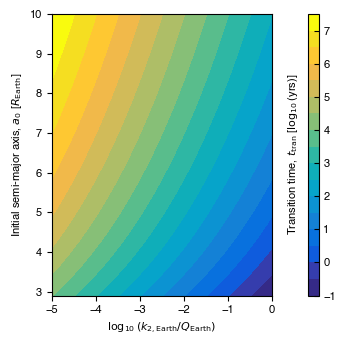

In [22]:
print('begin')

#plot a publication-quality figure

#initialise the figure
fig = plt.figure(figsize=(3.5,3.5))
gs = gridspec.GridSpec(1, 2,
                      width_ratios=[1,0.05],
                      height_ratios=[1])
ax=[[]]
ax[0].append(plt.subplot(gs[0]))

ax_col=[[]]
ax_col[0].append(plt.subplot(gs[1]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)
  
t_contours=np.linspace(-1,7.5,18) 

contour0 = ax[0][0].contourf(KKK, RRR/REarth, TTT1, levels=t_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(t_contours)-1)))

ax[0][0].set_xlabel(r"$\log_{10} \left ( k_{2,\mathrm{Earth}}/Q_\mathrm{Earth} \right )$")
ax[0][0].set_ylabel(r"Initial semi-major axis, $a_0$ [$R_\mathrm{Earth}$]")

cbar0=plt.colorbar(contour0, cax=ax_col[0][0], orientation='vertical')#,ticks=Alabels)

cbar0.set_label(r'Transition time, $t_\mathrm{tran}$ [$\log_{10}$(yrs)]', labelpad=-36)

ax_col[0][0].tick_params(direction="in")

fig.tight_layout()
plt.savefig('FigureA3.pdf')

print('done')

In [23]:
########################################################
########################################################
#considering cases with logarythmically and linearly increasing k2/Q

#use a cosntant a0
a0=2.9*REarth
Ltot=LEM

#set the initial and final k2Q

#increasing k2Q
k2Qmin=1E-5
k2Qmax=0.3/100 #0.3# 0.02

#alternative for decreaing k2Q
# k2Qmin=1.2
# k2Qmax=1E-2

#plot both a log and lin model
Nmodel=2

#consider a range of times at which the maximum k2Q is reached
tmax=np.asarray([0,0.1,1,10])*1E6*const.year
Ntmax=np.size(tmax)

#resulting expoential constant
sigma=np.log(k2Qmax/k2Qmin)/tmax
sigma[0]=0.0
print(sigma)

#number of time points
Nt=1000
t=np.logspace(3,8,Nt)*const.year


#run through and extract lengths and areas at each time point
k2Q=np.zeros((Nt,Nmodel,Ntmax))
a=np.zeros((Nt,Nmodel,Ntmax))
L=np.zeros((Nt,Nmodel,Ntmax))

dLdt=np.zeros((Nt,Nmodel,Ntmax))

dl_lat=np.empty((Nt,Nmodel,Ntmax,Nmu))
dl_lon=np.empty((Nt,Nmodel,Ntmax,Nmu))
dA=np.empty((Nt,Nmodel,Ntmax,Nmu))

ddl_lat_dL=np.zeros((Nt,Nmodel,Ntmax,Nmu))
ddl_lon_dL=np.zeros((Nt,Nmodel,Ntmax,Nmu))
ddA_dL=np.zeros((Nt,Nmodel,Ntmax,Nmu))

ddl_lat_dt=np.zeros((Nt,Nmodel,Ntmax,Nmu))
ddl_lon_dt=np.zeros((Nt,Nmodel,Ntmax,Nmu))
ddA_dt=np.zeros((Nt,Nmodel,Ntmax,Nmu))


for kk in np.arange(Nmodel):
    print(kk+1,'/',Nmodel)
    for i in np.arange(Ntmax):
        print('\t',i+1,'/',Ntmax)
        for j in np.arange(Nt):
            print('\t \t',j+1,'/',Nt)

            #for exponential growth
            if kk==0:
                if sigma[i]==0.0: #this is the constant k2Q=k2Qmax
                    k2Q[j,kk,i]=k2Qmax
                    integral=t[j]*k2Q[j,kk,i]
                elif t[j]<tmax[i]:
                    k2Q[j,kk,i]=k2Qmin*np.exp(sigma[i]*t[j])
                    integral=k2Qmin*(np.exp(sigma[i]*t[j])-1)/sigma[i]
                elif t[j]>=tmax[i]:
                    k2Q[j,kk,i]=k2Qmax
                    integral=k2Qmin*(np.exp(sigma[i]*tmax[i])-1)/sigma[i]+k2Qmax*(t[j]-tmax[i])
                    
            #for linear growth
            if kk==1:
                if sigma[i]==0.0: #this is the constant k2Q=k2Qmin
                    k2Q[j,kk,i]=k2Qmin
                    integral=t[j]*k2Q[j,kk,i]
                elif t[j]<tmax[i]:
                    k2Q[j,kk,i]=k2Qmin+(t[j]/tmax[i])*(k2Qmax-k2Qmin)
                    integral=k2Qmin*t[j]+((t[j]**2)/2/tmax[i])*(k2Qmax-k2Qmin)
                elif t[j]>=tmax[i]:
                    k2Q[j,kk,i]=k2Qmax
                    integral=k2Qmin*tmax[i]+0.5*tmax[i]*(k2Qmax-k2Qmin)+k2Qmax*(t[j]-tmax[i])

            #calculate the orbit
            kappa=3.0*k2Q[j,kk,i]*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))
            a[j,kk,i]=((13.0/2.0)*kappa*integral/k2Q[j,kk,i]+(a0**(13.0/2.0)))**(2.0/13.0)
            L[j,kk,i]=Ltot-(MMoon)*np.sqrt(const.G*a[j,kk,i]*(MEarth+MMoon))
            dLdt[j,kk,i]=-0.5*MMoon/np.sqrt(const.G*a[j,kk,i]*(MEarth+MMoon))*const.G*(MEarth+MMoon)*kappa*(a[j,kk,i]**(-11.0/2.0))

            temp_data=Hdatabase.interp_database(L[j,kk,i],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                               [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)

            temp=np.asarray(temp_data[16])

            dl_lat[j,kk,i,:]=temp[:,0]
            dl_lon[j,kk,i,:]=temp[:,1]
            dA[j,kk,i,:]=temp[:,2]

            ddl_lat_dL[j,kk,i,:]=temp[:,3]*np.pi/180.0
            ddl_lon_dL[j,kk,i,:]=temp[:,4]*np.pi/180.0
            ddA_dL[j,kk,i,:]=temp[:,5]*(np.pi/180.0)**2

            ddl_lat_dt[j,kk,i,:]=temp[:,3]*dLdt[j,kk,i]*np.pi/180.0
            ddl_lon_dt[j,kk,i,:]=temp[:,4]*dLdt[j,kk,i]*np.pi/180.0
            ddA_dt[j,kk,i,:]=temp[:,5]*dLdt[j,kk,i]*(np.pi/180.0)**2

        

/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_8288/1750907732.py:27: RuntimeWarning: divide by zero encountered in divide
  sigma=np.log(k2Qmax/k2Qmin)/tmax


[0.00000000e+00 1.80865756e-12 1.80865756e-13 1.80865756e-14]
1 / 2
	 1 / 4
	 	 1 / 1000
	 	 2 / 1000
	 	 3 / 1000
	 	 4 / 1000
	 	 5 / 1000
	 	 6 / 1000
	 	 7 / 1000
	 	 8 / 1000
	 	 9 / 1000
	 	 10 / 1000
	 	 11 / 1000
	 	 12 / 1000
	 	 13 / 1000
	 	 14 / 1000
	 	 15 / 1000
	 	 16 / 1000
	 	 17 / 1000
	 	 18 / 1000
	 	 19 / 1000
	 	 20 / 1000
	 	 21 / 1000
	 	 22 / 1000
	 	 23 / 1000
	 	 24 / 1000
	 	 25 / 1000
	 	 26 / 1000
	 	 27 / 1000
	 	 28 / 1000
	 	 29 / 1000
	 	 30 / 1000
	 	 31 / 1000
	 	 32 / 1000
	 	 33 / 1000
	 	 34 / 1000
	 	 35 / 1000
	 	 36 / 1000
	 	 37 / 1000
	 	 38 / 1000
	 	 39 / 1000
	 	 40 / 1000
	 	 41 / 1000
	 	 42 / 1000
	 	 43 / 1000
	 	 44 / 1000
	 	 45 / 1000
	 	 46 / 1000
	 	 47 / 1000
	 	 48 / 1000
	 	 49 / 1000
	 	 50 / 1000
	 	 51 / 1000
	 	 52 / 1000
	 	 53 / 1000
	 	 54 / 1000
	 	 55 / 1000
	 	 56 / 1000
	 	 57 / 1000
	 	 58 / 1000
	 	 59 / 1000
	 	 60 / 1000
	 	 61 / 1000
	 	 62 / 1000
	 	 63 / 1000
	 	 64 / 1000
	 	 65 / 1000
	 	 66 / 1000
	 	 67 / 

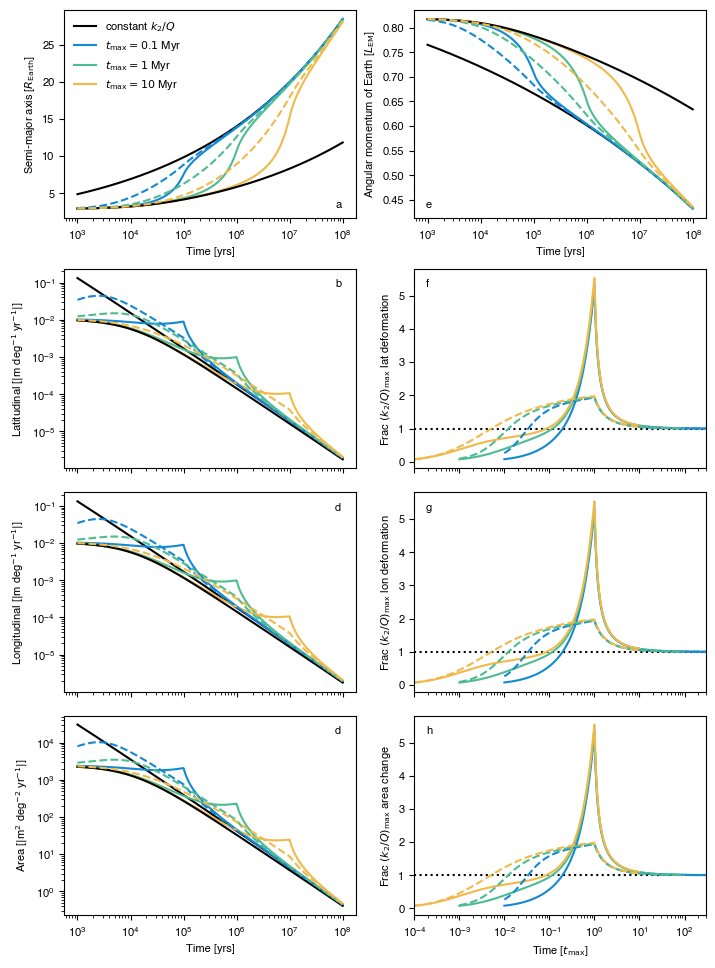

In [24]:
#Combine the previous two plots into one for final paper

#initialise the figure
fig = plt.figure(figsize=(7.2,9.724))
gs0 = gridspec.GridSpec(2, 1,height_ratios=[1,3.1])


gs00 = gridspec.GridSpecFromSubplotSpec(1, 2, 
                                        subplot_spec=gs0[0]
                                        )


gs01 = gridspec.GridSpecFromSubplotSpec(3, 2, 
                                        subplot_spec=gs0[1]
                                        )

ax=[[],[]]
ax[0].append(plt.subplot(gs00[0]))
ax[1].append(plt.subplot(gs00[1]))

ax[0].append(plt.subplot(gs01[0]))
ax[0].append(plt.subplot(gs01[2],sharex=ax[0][1]))
ax[0].append(plt.subplot(gs01[4],sharex=ax[0][1]))

ax[1].append(plt.subplot(gs01[1]))
ax[1].append(plt.subplot(gs01[3],sharex=ax[1][1]))
ax[1].append(plt.subplot(gs01[5],sharex=ax[1][1]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)



labels=[r'constant $k_2/Q$',r'$t_\mathrm{max}=0.1$ Myr',r'$t_\mathrm{max}=1$ Myr',r'$t_\mathrm{max}=10$ Myr']

line=['-','--']
col=cmaps.parula(np.linspace(0,0.8,Ntmax))

ax[1][1].plot([1E-4,3E2],[1,1],'k:')
ax[1][2].plot([1E-4,3E2],[1,1],'k:')
ax[1][3].plot([1E-4,3E2],[1,1],'k:')

ind_mu=0
for kk in np.arange(Nmodel):
    for i in np.arange(0,Ntmax):
        
        if sigma[i]==0.0:
            #add labels to plot on first round
            if (kk==0):
                ax[0][0].plot(t/const.year,a[:,kk,i]/REarth,
                              'k-',label=labels[i])

            else:
                ax[0][0].plot(t/const.year,a[:,kk,i]/REarth,'k-')

            ax[0][1].plot(t/const.year,np.absolute(ddl_lat_dt[:,kk,i,ind_mu])*const.year,'k-')
            ax[0][2].plot(t/const.year,np.absolute(ddl_lon_dt[:,kk,i,ind_mu])*const.year,'k-')
            ax[0][3].plot(t/const.year,np.absolute(ddA_dt[:,kk,i,ind_mu])*const.year,'k-')
            
            ax[1][0].plot(t/const.year,L[:,kk,i]/LEM,'k-')
            
        else:
            #add labels to plot on first round
            if (kk==0):
                ax[0][0].plot(t/const.year,a[:,kk,i]/REarth,
                              line[kk],color=col[i],label=labels[i])

            else:
                ax[0][0].plot(t/const.year,a[:,kk,i]/REarth,line[kk],color=col[i])

            ax[0][1].plot(t/const.year,np.absolute(ddl_lat_dt[:,kk,i,ind_mu])*const.year,line[kk],color=col[i])
            ax[0][2].plot(t/const.year,np.absolute(ddl_lon_dt[:,kk,i,ind_mu])*const.year,line[kk],color=col[i])
            ax[0][3].plot(t/const.year,np.absolute(ddA_dt[:,kk,i,ind_mu])*const.year,line[kk],color=col[i])
        

            ax[1][0].plot(t/const.year,L[:,kk,i]/LEM,line[kk],color=col[i])

            if k2Qmin>k2Qmax:
                ax[1][1].plot(t/tmax[i],1.0/((np.absolute(ddl_lat_dt[:,kk,i,ind_mu]))/np.absolute(ddl_lat_dt[:,0,0,ind_mu])),line[kk],color=col[i])
                ax[1][2].plot(t/tmax[i],1.0/((np.absolute(ddl_lon_dt[:,kk,i,ind_mu]))/np.absolute(ddl_lon_dt[:,0,0,ind_mu])),line[kk],color=col[i])
                ax[1][3].plot(t/tmax[i],1.0/((np.absolute(ddA_dt[:,kk,i,ind_mu]))/np.absolute(ddA_dt[:,0,0,ind_mu])),line[kk],color=col[i])
            else:
                ax[1][1].plot(t/tmax[i],(np.absolute(ddl_lat_dt[:,kk,i,ind_mu]))/np.absolute(ddl_lat_dt[:,0,0,ind_mu]),line[kk],color=col[i])
                ax[1][2].plot(t/tmax[i],(np.absolute(ddl_lon_dt[:,kk,i,ind_mu]))/np.absolute(ddl_lon_dt[:,0,0,ind_mu]),line[kk],color=col[i])
                ax[1][3].plot(t/tmax[i],(np.absolute(ddA_dt[:,kk,i,ind_mu]))/np.absolute(ddA_dt[:,0,0,ind_mu]),line[kk],color=col[i])
            
  
ax[0][0].legend(frameon=False)

ax[1][1].set_xlim([1E-4,3E2])
    
for i in np.arange(4):
    if (i!=0):
        ax[0][i].set_yscale('log')
    ax[0][i].set_xscale('log')
    ax[1][i].set_xscale('log')

    if (i!=3)&(i!=0):
        plt.setp( ax[0][i].get_xticklabels(), visible=False)
        plt.setp( ax[1][i].get_xticklabels(), visible=False)
 
ax[0][0].set_ylabel(r'Semi-major axis [$R_\mathrm{Earth}$]')
ax[1][0].set_ylabel(r'Angular momentum of Earth [$L_\mathrm{EM}$]')

ax[0][1].set_ylabel(r'Latitudinal [$|$m deg$^{-1}$ yr$^{-1}$$|$]')
ax[0][2].set_ylabel(r'Longitudinal [$|$m deg$^{-1}$ yr$^{-1}$$|$]')
ax[0][3].set_ylabel(r'Area [$|$m$^2$ deg$^{-2}$ yr$^{-1}$$|$]')

if k2Qmin>k2Qmax:
    ax[1][1].set_ylabel(r'Inv frac $k_2/Q_\mathrm{min}$ lat deformation')
    ax[1][2].set_ylabel(r'Inv frac $k_2/Q_\mathrm{min}$ lon deformation')
    ax[1][3].set_ylabel(r'Inv frac $k_2/Q_\mathrm{min}$ area change')
else:
    ax[1][1].set_ylabel(r'Frac $(k_2/Q)_\mathrm{max}$ lat deformation')
    ax[1][2].set_ylabel(r'Frac $(k_2/Q)_\mathrm{max}$ lon deformation')
    ax[1][3].set_ylabel(r'Frac $(k_2/Q)_\mathrm{max}$ area change')

ax[0][0].set_xlabel(r'Time [yrs]')
ax[1][0].set_xlabel(r'Time [yrs]')
ax[0][3].set_xlabel(r'Time [yrs]')
ax[1][3].set_xlabel(r'Time [$t_\mathrm{max}$]')

#label axis
ax[0][0].text(0.95, 0.04, 'a', horizontalalignment='right',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.95, 0.95, 'b', horizontalalignment='right',verticalalignment='top', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[0][2].text(0.95, 0.95, 'd', horizontalalignment='right',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.95, 0.95, 'd', horizontalalignment='right',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')

ax[1][0].text(0.04, 0.04, 'e', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[1][0].transAxes, color='k')
ax[1][1].text(0.04, 0.95, 'f', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[1][1].transAxes, color='k')
ax[1][2].text(0.04, 0.95, 'g', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[1][2].transAxes, color='k')
ax[1][3].text(0.04, 0.95, 'h', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[1][3].transAxes, color='k')


#ax[0][1].set_ylim([1,1.1])

fig.tight_layout()
plt.savefig('FigureA4.pdf')
        

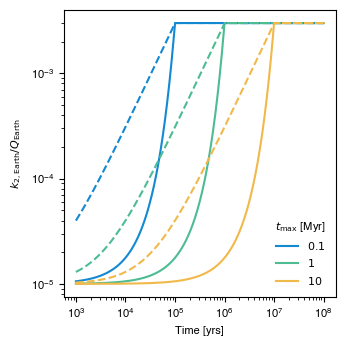

In [25]:
#plot the time evolution of k2/Q

#initialise the figure
fig = plt.figure(figsize=(3.5,3.5))
gs = gridspec.GridSpec(1, 1)
ax=[[]]
ax[0].append(plt.subplot(gs[0]))


labels=['', r'$0.1$',r'$1$',r'$10$']

line=['-','--']
col=cmaps.parula(np.linspace(0,0.8,Ntmax))

for kk in np.arange(Nmodel):
    for i in np.arange(1,Ntmax):
        
        if sigma[i]==0.0:
            #add labels to plot on first round
            if (kk==0):
                ax[0][0].plot(t/const.year,k2Q[:,kk,i],
                              'k-',label=labels[i])

            else:
                ax[0][0].plot(t/const.year,k2Q[:,kk,i],'k-')
            
        else:
            #add labels to plot on first round
            if (kk==0):
                ax[0][0].plot(t/const.year,k2Q[:,kk,i],
                              line[kk],color=col[i],label=labels[i])

            else:
                ax[0][0].plot(t/const.year,k2Q[:,kk,i],line[kk],color=col[i])


ax[0][0].legend(frameon=False, title=r'$t_{\rm max}$ [Myr]', loc='lower right')

ax[0][0].set_xscale('log')
ax[0][0].set_yscale('log')

ax[0][0].set_xlabel('Time [yrs]')
ax[0][0].set_ylabel(r'$k_{2,{\rm Earth}}/Q_{\rm Earth}$')


fig.tight_layout()

plt.savefig('Figure2.pdf')

